### This notebook illustrates the main ideas of the BMS vs ANN approximation at one-dimensional functions.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par

### Functions and figure settings

In [7]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,dimensions=False ):
    
    #Parameters to read models
    if dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #one or two dimensional nguyen functions
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
        
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/tutorial/'      
extensions=['.svg', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 8*cm; height=7*cm 
#--------------------------------

#Text and figure sizes  
#--------------------------------
size_axis=16;size_ticks=12;size_title=8
line_w=1.5;marker_s=4
#--------------------------------

#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }
#color_data=sns.color_palette("colorblind")[0]
#color_noise=sns.color_palette("colorblind")[7]
#color_ann=sns.color_palette("colorblind")[4]
#color_bms=sns.color_palette("colorblind")[2]

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

#ticks and limits for ann 
#--------------------------------
xtick_labels=[-2, 0, 2 ];ytick_labels=[ 0, 0.5, 1.0]
xmin=-2.04;xmax=2.04;ymin=-0.1;ymax=1.1
#--------------------------------

#ticks and limits for ng1 functions
#--------------------------------
xtick_labels_ng1=[-1, 0, 1 ];ytick_labels_ng1=[ -3, 0, 3, 6.0]
xmin_ng1=-1.1;xmax_ng1=1.1;ymin_ng1=-3.25;ymax_ng1=7
#--------------------------------

#ticks and limits for ng10 functions
#--------------------------------
xtick_labels_ng10=[0, 0.5, 1 ];ytick_labels_ng10=[ 0, 0.5, 1.0];ztick_labels_ng10=[ 0, 0.5, 1.0]
xmin_ng10=-0.1;xmax_ng10=1.1;ymin_ng10=-0.1;ymax_ng10=1.1;
zmin_ng10=-0.1;zmax_ng10=1
#--------------------------------



## Read input data

In [8]:
#Read ANN-generated data and model                                                                                        
activation_function='tanh'; n=8;sigma=0.0; realization=2  #parameters
path_nn='../data/tutorial/'
file_data= path_nn + 'NN_no_overfit_test_full_train_tanh_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
d=pd.read_csv(file_data, index_col=0)
dn=d[d['rep']==n] #select n=7
dn=dn[(dn['x1']>=-2.0) & (dn['x1']<=2.0)] #take points between x=-2/+2
display(dn)

#Read BMS with 10 parameters and run in 50 k steps
steps=50000;NPAR=10
path_trace= '../data/tutorial/'
filename=path_trace +'BMS_' + activation_function + '_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_0.05_trace_'+str(steps)+'_prior_10'+ '.csv'

trace0=pd.read_csv(filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t0,x0,y0=get_mdl(dn, trace0)

display(trace0)

,x1,y,rep,noise,y_noise,ymodel
0,-1.95,0.029264,8.0,0.0,0.029264,0.029652
1,-1.90,0.031695,8.0,0.0,0.031695,0.032006
2,-1.85,0.034179,8.0,0.0,0.034179,0.034402
3,-1.80,0.036709,8.0,0.0,0.036709,0.036839
4,-1.75,0.039279,8.0,0.0,0.039279,0.039318
...,...,...,...,...,...,...
75,1.80,0.983012,8.0,0.0,0.983012,0.982763
76,1.85,0.986217,8.0,0.0,0.986217,0.986216
77,1.90,0.989010,8.0,0.0,0.989010,0.989330
78,1.95,0.991424,8.0,0.0,0.991424,0.992141


<lambdifygenerated-164>:2: RuntimeWarning: invalid value encountered in power
  return (x1 + x1**x1)/x1
<lambdifygenerated-165>:2: RuntimeWarning: invalid value encountered in power
  return (x1 + x1**x1)/x1
<lambdifygenerated-174>:2: RuntimeWarning: invalid value encountered in power
  return (x1 + (x1**2*(_a1_ + x1**x1)**2)**x1)/x1
/export/home/shared/Projects/ANN/Sergio/BMS_approximator/tutorial/../bin/no_degeneracy/mcmc.py:654: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(
<lambdifygenerated-175>:2: RuntimeWarning: invalid value encountered in power
  return (x1 + (x1**2*(_a1_ + x1**x1)**2)**x1)/x1
<lambdifygenerated-176>:2: RuntimeWarning: invalid value encountered in power
  return (x1 + (x1**2*(_a1_ + (2*x1)**x1)**2)**x1)/x1
<lambdifygenerated-177>:2: RuntimeWarning: invalid value encountered in power
  return (x1 + (x1**2*(_a1_ + (2*x1)**x1)**2)**x1)/x1
<lambdifygenerated-178>:2: RuntimeWarning: invalid value encountered in power
  retu

,t,H,expr,parvals,kk1,kk2,kk3
0,0,3.781050,_a7_,"{'d0': {'_a7_': 0.21831000970961179, '_a0_': 1...",{'d0': 3.476494102877787},7.562100,0.000000
1,1,3.781050,_a7_,"{'d0': {'_a7_': 0.21831000970961179, '_a0_': 1...",{'d0': 3.476494102877787},7.562100,0.000000
2,2,3.781050,_a7_,"{'d0': {'_a7_': 0.21831000970961179, '_a0_': 1...",{'d0': 3.476494102877787},7.562100,0.000000
3,3,3.781050,_a7_,"{'d0': {'_a7_': 0.21831000970961179, '_a0_': 1...",{'d0': 3.476494102877787},7.562100,0.000000
4,4,3.781050,_a7_,"{'d0': {'_a7_': 0.21831000970961179, '_a0_': 1...",{'d0': 3.476494102877787},7.562100,0.000000
...,...,...,...,...,...,...,...
49995,49995,-391.496389,((((pow2((((_a2_ * (_a1_ * (_a5_ * pow2(_a5_))...,"{'d0': {'_a0_': 1.5912968203268714, '_a1_': -3...",{'d0': 3.6621050698713935e-08},-1065.897505,141.452364
49996,49996,-391.496389,((((pow2((((_a2_ * (_a1_ * (_a5_ * pow2(_a5_))...,"{'d0': {'_a0_': 1.5912968203268714, '_a1_': -3...",{'d0': 3.6621050698713935e-08},-1065.897505,141.452364
49997,49997,-391.496389,((((pow2((((_a2_ * (_a1_ * (_a5_ * pow2(_a5_))...,"{'d0': {'_a0_': 1.5912968203268714, '_a1_': -3...",{'d0': 3.6621050698713935e-08},-1065.897505,141.452364
49998,49998,-391.496389,((((pow2((((_a2_ * (_a1_ * (_a5_ * pow2(_a5_))...,"{'d0': {'_a0_': 1.5912968203268714, '_a1_': -3...",{'d0': 3.6621050698713935e-08},-1065.897505,141.452364


### Consider the example function read in the previous cell

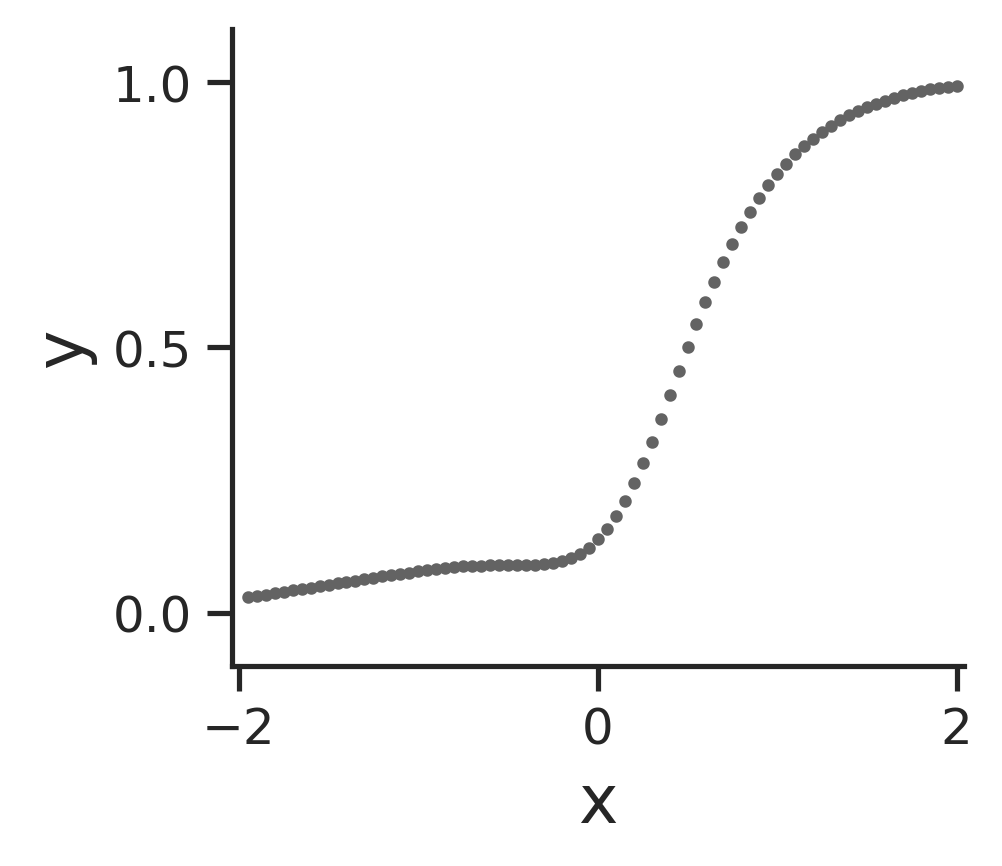

In [9]:
#Plot example function
#--------------------------------            
fig=figure(figsize=(width,height), dpi=300) 
plt.plot(dn.x1,dn.y,'.', color=color_data, markersize=marker_s)
#--------------------------------  

#Labels and ticks                                                              
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)                                                              
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)

sns.despine(top=True, right=True)

#save fig  
name_fig='example_function_n' + str(n)
for ext in extensions:
    plt.savefig(output_path+name_fig+ext,dpi=300)

plt.show()
#-------------------------------- 

# Suppose we approximate the function with a neural network:

![alt text](figures/ann_1.png "ANN with 5 layers and 10 nodes per layer")

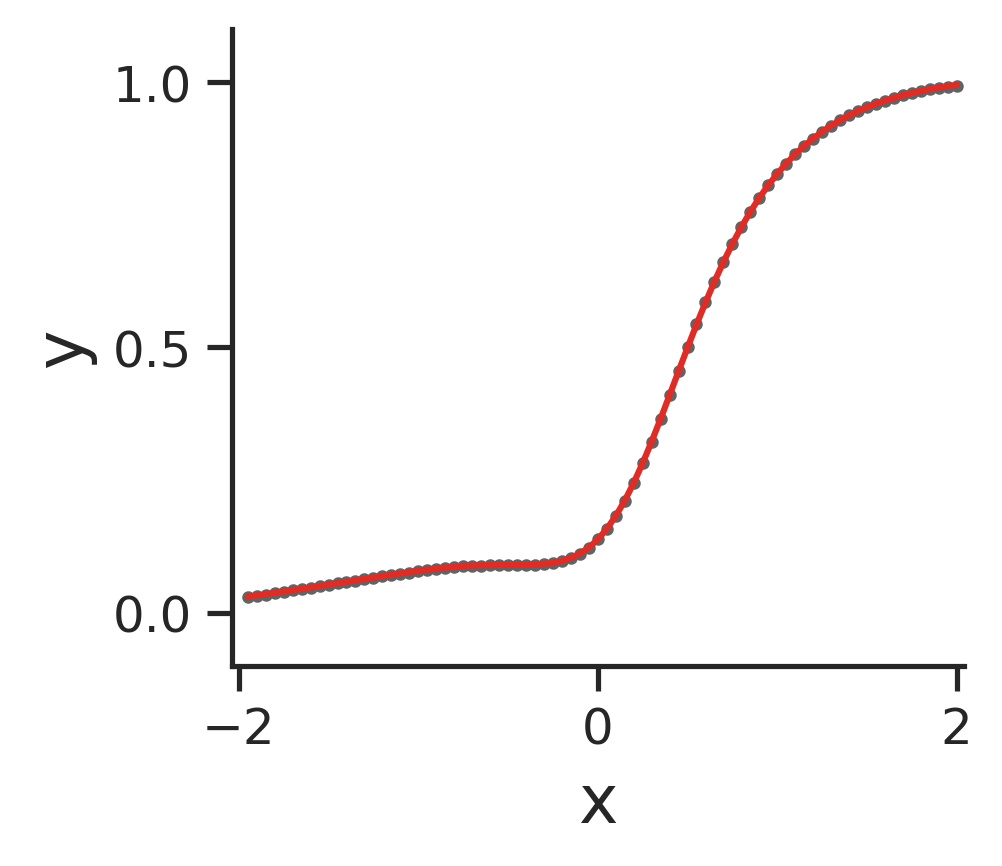

In [10]:
fig=figure(figsize=(width,height), dpi=300) 

#calculate root mean squared error
rmse_nn_total=root_mean_squared_error(dn.ymodel,dn.y)

#Plots                                                               
#--------------------------------                                    
plt.plot(dn.x1,dn.y,'.', color=color_data,markersize=marker_s)
plt.plot(dn.x1,dn.ymodel, color=color_ann, label='ann.  rmse= %.1E' % rmse_nn_total)
#--------------------------------

#Labels                                                              
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
#Ticks                                                               
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)

#plt.legend(loc='best', fontsize=size_title)

sns.despine(top=True, right=True)

#save fig  
name_fig='ann_full_prediction'
for ext in extensions:
    plt.savefig(output_path+name_fig+ext,dpi=300)

plt.show()
#-------------------------------- 

# Suppose now that we train the Bayesian Machine Scientist with 10 parameters and let it sample the space in 50k steps

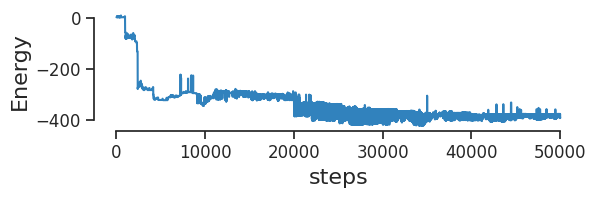

In [11]:
#Plot energy vs steps
plt.figure(figsize=(16*cm, 4*cm))

Nini = 00
minrow = trace0[trace0.H == min(trace0.H)].iloc[0]
#minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

plt.plot(trace0.t[trace0.t > Nini], trace0.H[trace0.t > Nini],color=color_bms)

plt.xlabel('steps',fontsize=size_axis);plt.ylabel('Energy',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)

sns.despine(trim=True)
namefig='Energy_' + activation_function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

for ext in extensions:
        plt.savefig(output_path + namefig + ext,dpi=300)

 
plt.show()

# We now show the approximation of the equation generated by the BMS

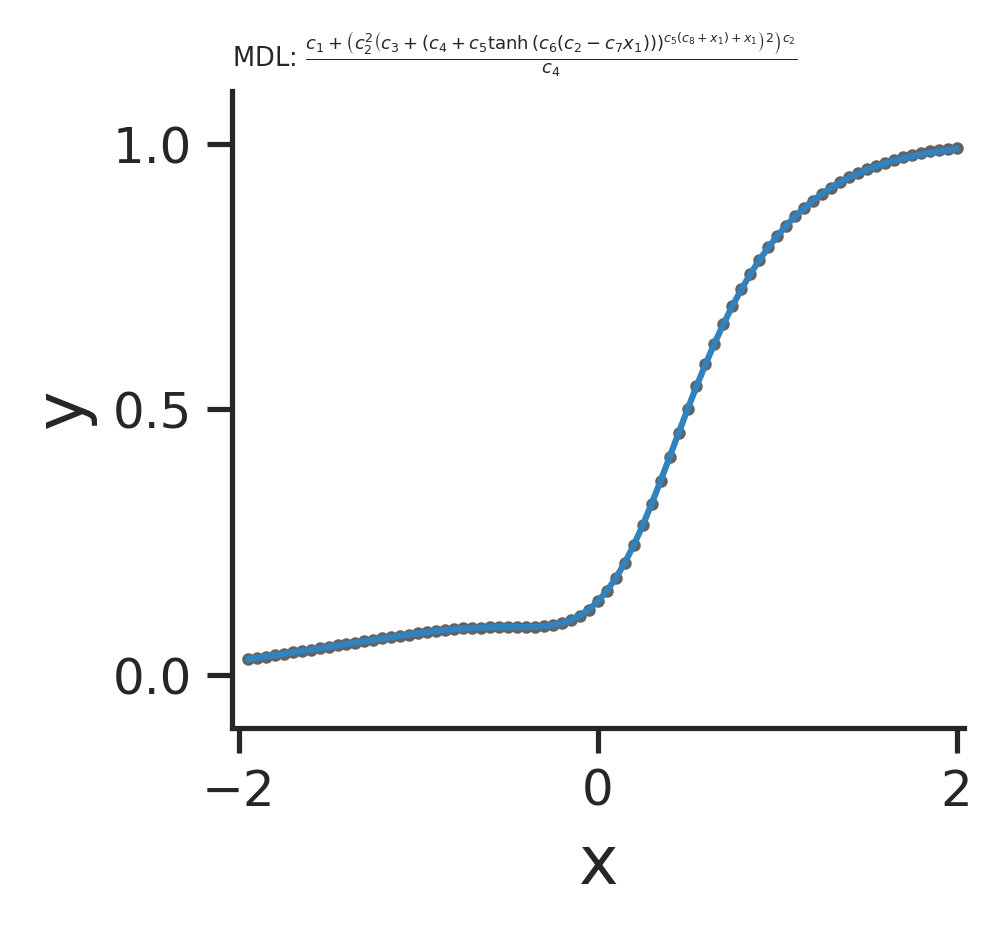

In [12]:
#copy the original dataframe and add a column for the prediction of the BMS
dplot = deepcopy(dn)
dplot['ybms'] = t0.predict(x0)

#calculate rmse
rmse_mdl=root_mean_squared_error(dplot['ybms'],dn['y'])

#Define figure size in cm                                                                                                                                   
fig=figure(figsize=(width,height), dpi=300) 

plt.plot(dn['x1'], dn['y'],'.', markersize=marker_s, color=color_data) 
plt.plot(dplot.x1, dplot.ybms, color=color_bms,label='bms.  rmse= %.1E' % ( rmse_mdl))

plt.title('MDL: $%s$' % t0.latex(),loc='left',fontsize=size_title-1.8)
plt.xlabel('x',fontsize=size_axis);plt.ylabel("y",fontsize=size_axis)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)  

#plt.legend(loc='best', fontsize=size_title)

sns.despine(top=True, right=True)

namefig='bms_full_prediction'
for ext in extensions:
        plt.savefig(output_path + namefig +ext,dpi=300)

plt.show()


## The equation found by the BMS approximates the same function with an error on the same order of magnitude and just 10 parameters

You think that is a complex equation? You are right, but bear in mind that the ANN that I showed you above performs 522 operations per data point. That function has 80 points.

This is just an example so we are going to do two experiments to test our hypothesis that the BMS approximates one-dimensional functions more efficiently than ANNs

### Experiment 1: Can ANNs and the BMS approximate actual mathematical functions?

 To see that, we take two functions from the [Nguyen Dataset](https://doi.org/10.1007/978-3-642-04962-0_7). In particular, we take function 1 and 10:

$$f_1=3.39 x^3 + 2.12 x^2 +  1.78 x$$

$$f_{10}=\sin(1.5 x) \cos(0.5 y)$$

First, we read the datasets with data generated from those functions.

In [15]:
#Read Nguyen data

#Read nguyen data
#-------------------------------------------------------------------------------
sigma=0.0;

realization=2

NPAR=10 #10, 20
steps=50000
path_nguyen_nn= '../data/nns/nguyen/'
file_model_ng1= path_nguyen_nn + 'NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
dng=pd.read_csv(file_model_ng1,index_col=0)
#-------------------------------------------------------------------------------

#Read n1 trace
#-------------------------------------------------------------------------------
n1=1
dng1=dng[dng['rep']==1]
#Read bms trace for nguyen 1
path_nguyen_bms='../data/MSTraces/nguyen/'
trace_ng1=path_nguyen_bms + 'BMS_nguyen_n_' + str(n1)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_10'+ '.csv'
trace1=pd.read_csv(trace_ng1, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t1,x1,y1=get_mdl(dng1, trace1)
#-------------------------------------------------------------------------------

#Read n10 trace
#-------------------------------------------------------------------------------
n2=10
dng10=dng[dng['rep']==n2]
dng10=dng10.reset_index(drop=True)
trace_ng10=path_nguyen_bms + 'BMS_nguyen_n_' + str(n2)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_10'+ '.csv'
trace10=pd.read_csv(trace_ng10, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t10,x10,y10=get_mdl(dng10, trace10,dimensions=True)
#-------------------------------------------------------------------------------

Then we plot the actual functions:

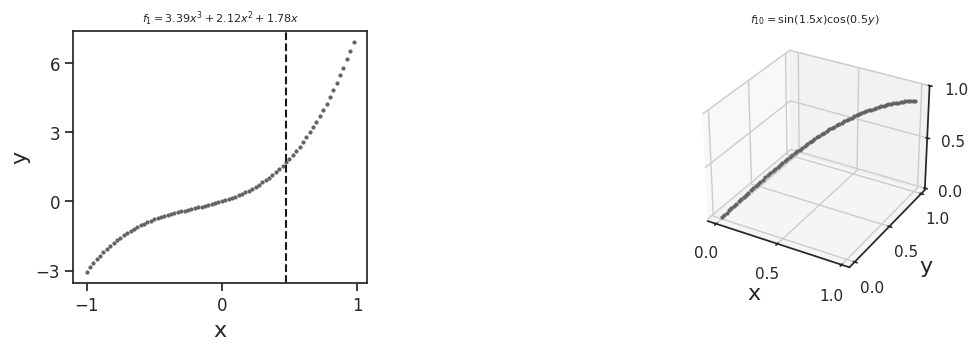

In [17]:
#Settings panel
width_p=30*cm;height_p=20*cm #Width and height of plots                                                  
matplotlib.rcParams['figure.figsize'] = [width_p, height_p]
rows=2;cols=3
gs=gridspec.GridSpec(rows,cols)
gs.update(left=0.05,right=0.97,bottom=0.1,top=0.95,wspace=0.35,hspace=0.65)

train_size=60
train_border=dng1.loc[train_size-1]['x']

#Nguyen1                                                                                             
ax_00=plt.subplot(gs[0,0])
plt.title(r'$f_1=3.39 x^3 + 2.12 x^2 +1.78x$',fontsize=size_title)
plt.plot(dng1.x,dng1.z, '.', markersize=marker_s, color=color_data, label='f1')
plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(xtick_labels_ng1, fontsize=size_ticks);plt.yticks(ytick_labels_ng1, fontsize=size_ticks)

namefig='nguyen1'
for ext in extensions:
        plt.savefig(output_path + namefig +ext,dpi=300)


#Nguyen10                                                                                             
ax_01 = plt.subplot(gs[0,1:3], projection='3d')
plt.title(r'$f_{10}=\sin(1.5x) \cos(0.5y)$',fontsize=size_title)
ax_01.plot(dng10.x, dng10.y, dng10.z, '.', markersize=marker_s,color=color_data)
ax_01.set_xticks(xtick_labels_ng10);ax_01.set_yticks(ytick_labels_ng10);ax_01.set_zticks(ztick_labels_ng10)
ax_01.set_xlabel('x',fontsize=size_axis);ax_01.set_ylabel('y',fontsize=size_axis);ax_01.set_zlabel('z',fontsize=size_axis)

namefig='nguyen10'
for ext in extensions:
        plt.savefig(output_path + namefig +ext,dpi=300)

Next, we show how ANNs (light purple line) and the equation found by the BMS (solid teal line) approximate the function: $$f_1=3.39 x^3 + 2.12 x^2 +  1.78 x$$

We trained with 60 points and tested on the remaining 20 ones. 
In the case of neural networks, we also validated our results on 10-point validation set to prevent overfitting.

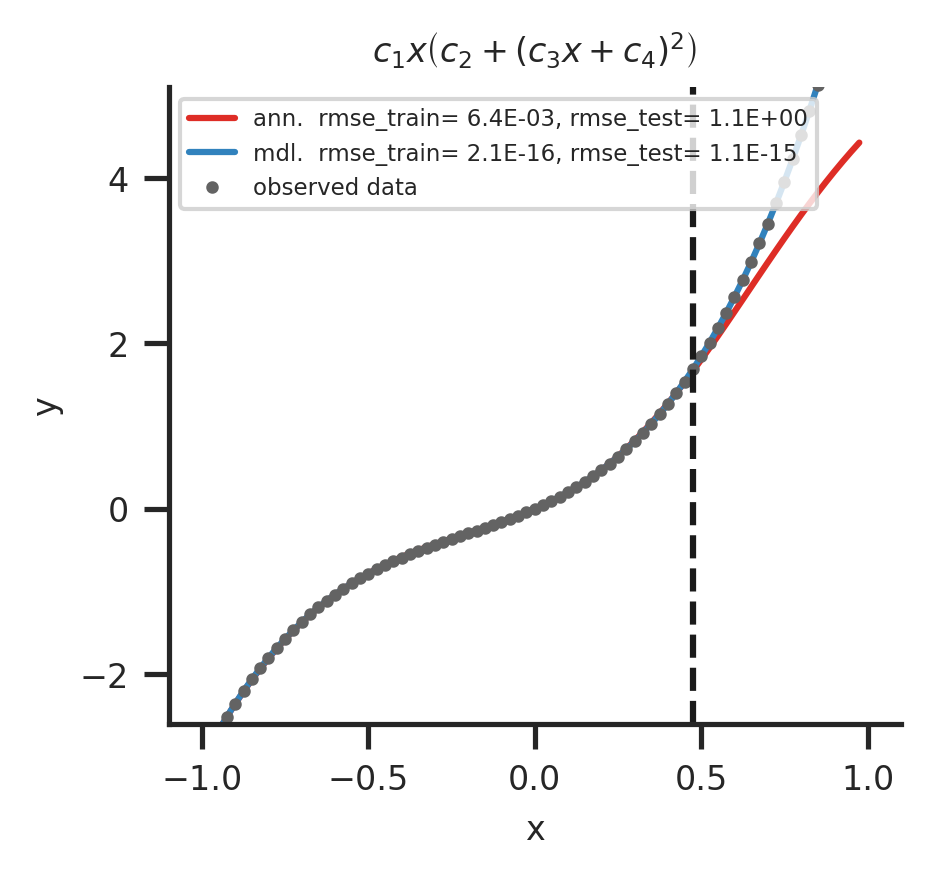

((_a2_ * x) * ((((x * _a0_) + _a3_) ** 2) + _a1_))

{'d0': {'_a0_': 2.128053445968343,
  '_a1_': 1.9350857962573627,
  '_a2_': 0.7485738229658999,
  '_a3_': 0.665409042102196,
  '_a4_': 1.0,
  '_a5_': 1.0,
  '_a6_': 1.0,
  '_a7_': 1.0}}

In [19]:
#copy dataframe and include predictions from the BMS
dplot = deepcopy(dng1)
dplot['ybms'] = t1.predict(x1)

#Compute rmse errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size-1]['zmodel'],dplot.loc[:train_size -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size-1:]['zmodel'],dplot.loc[train_size -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size-1]['ybms'],dplot.loc[:train_size-1]['z'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size-1:]['ybms'],dplot.loc[train_size-1:]['z'])


#Plot figure
fig=figure(figsize=(width,height), dpi=300)                                                        
plt.plot(dng1['x'], dng1['zmodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_nn_train, rmse_nn_test)) 
plt.plot(dplot.x, dplot.ybms, color=color_bms,label='mdl.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_mdl_train, rmse_mdl_test))
plt.plot(dng1['x'], dng1['z'],'.', markersize=marker_s, color=color_data,label='observed data') 

train_size=60
train_border=dng1.loc[train_size-1]['x']
plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

#Set title, labels, ticks, and legend
plt.title('$%s$' % t1.latex(),fontsize=size_title)
plt.xlabel('x',fontsize=size_title);plt.ylabel('y',fontsize=size_title)
plt.xticks(fontsize=size_title);plt.yticks(fontsize=size_title)
plt.legend(loc='best', fontsize=size_title-2.5)

#set limits and layout
plt.xlim(-1.1, 1.1);plt.ylim(-2.6,5.1)
sns.despine(top=True, right=True)

#Save figure
Name_figure='predictions_nguyen' + '_n_1' + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)
    
for ext in extensions:
        plt.savefig('../results/' + Name_figure +ext,dpi=300)

plt.show()


display(t1,t1.par_values)

We now show ANN and BMS-generated approximations for: $$f_{10}=\sin(1.5 x) \cos(0.5 y)$$

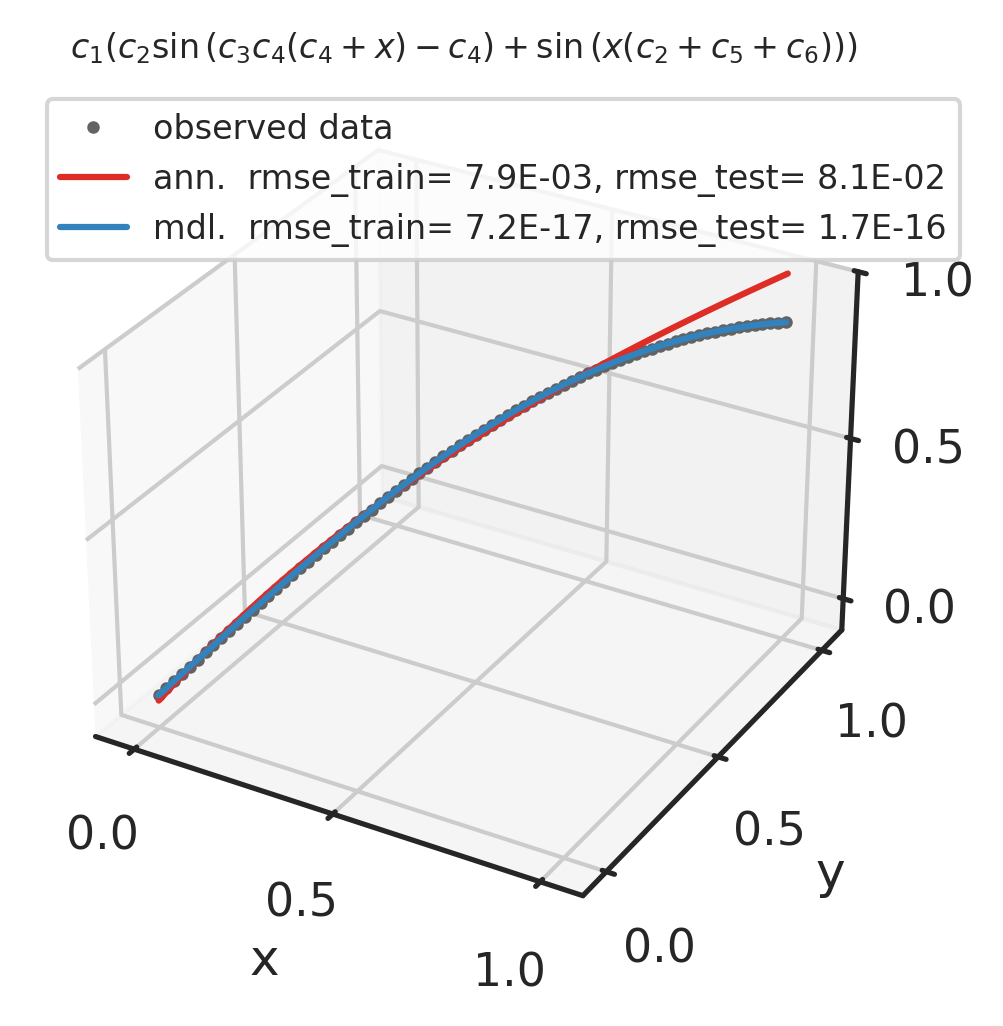

(((sin(((((x + _a5_) * _a0_) * _a5_) + -(_a5_))) * _a1_) + sin((x * ((_a4_ + _a1_) + _a6_)))) * _a7_)

{'d0': {'_a0_': 1.0266351791535708,
  '_a1_': 0.999999999999957,
  '_a4_': 0.4999890935495308,
  '_a5_': 0.9740558479833794,
  '_a6_': 0.5000109064505013,
  '_a7_': 0.5000000000000089,
  '_a2_': 1.0,
  '_a3_': 1.0}}

In [20]:
#copy dataframe and include predictions from the BMS
dplot10 = deepcopy(dng10)
dplot10['ybms'] = t10.predict(x10)

#Compute rmse errors
rmse_nn_train=root_mean_squared_error(dplot10.loc[:train_size-1]['zmodel'],dplot10.loc[:train_size -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot10.loc[train_size-1:]['zmodel'],dplot10.loc[train_size -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dplot10.loc[:train_size-1]['ybms'],dplot10.loc[:train_size-1]['z'])
rmse_mdl_test =root_mean_squared_error(dplot10.loc[train_size-1:]['ybms'],dplot10.loc[train_size-1:]['z'])

#Plot figure
#--------------------------------            
fig=figure(figsize=(width+1,height+1), dpi=300) 
ax=plt.subplot( projection='3d')                                                        
plt.plot(dplot10.x, dplot10.y, dplot10.z,'.', markersize=marker_s, color=color_data,label='observed data') 
plt.plot(dplot10.x, dplot10.y, dplot10.zmodel,linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_nn_train, rmse_nn_test)) 
plt.plot(dplot10.x, dplot10.y, dplot10.ybms, color=color_bms,label='mdl.  rmse_train= %.1E, rmse_test= %.1E' % ( rmse_mdl_train, rmse_mdl_test))
plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

#Set title, labels, ticks, and legend
plt.title('$%s$' % t10.latex(),fontsize=size_title)
ax.set_xlabel('x',fontsize=size_ticks);ax.set_ylabel('y',fontsize=size_ticks)
ax.set_xticks(xtick_labels_ng10);ax.set_yticks(ytick_labels_ng10);ax.set_zticks(ztick_labels_ng10)

ax.legend(loc='upper left', fontsize=size_title)

#set limits and layout
ax.set_xlim(xmin_ng10,xmax_ng10);ax.set_ylim(ymin_ng10,ymax_ng10);ax.set_zlim(zmin_ng10,zmax_ng10)

#Save figure
Name_figure='predictions_nguyen' + '_n_' + str(n2) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)
    
for ext in extensions:
        plt.savefig('../results/' + Name_figure +ext,dpi=300)

plt.show()


display(t10,t10.par_values)

These are fairly good results, but to a certain extent expected: you would expect a good symbolic regression tool such as the Bayesian Machine Scientist to recover the functions that generated the data originally. Now, what happens if we try to approximate a function generated by an Artificial Neural Network?

### Experiment 2 -  Can ANNs and the BMS approximate ANN-generated functions?

Let's take a look at a specific example. The function that I showed you at the beginning of this notebook was actually generated from a neural network with the exact same architecture as the one I used to train it. Now, I am going to do two things. First, I am going to add some gaussian noise $\sigma=0.04$ to it.


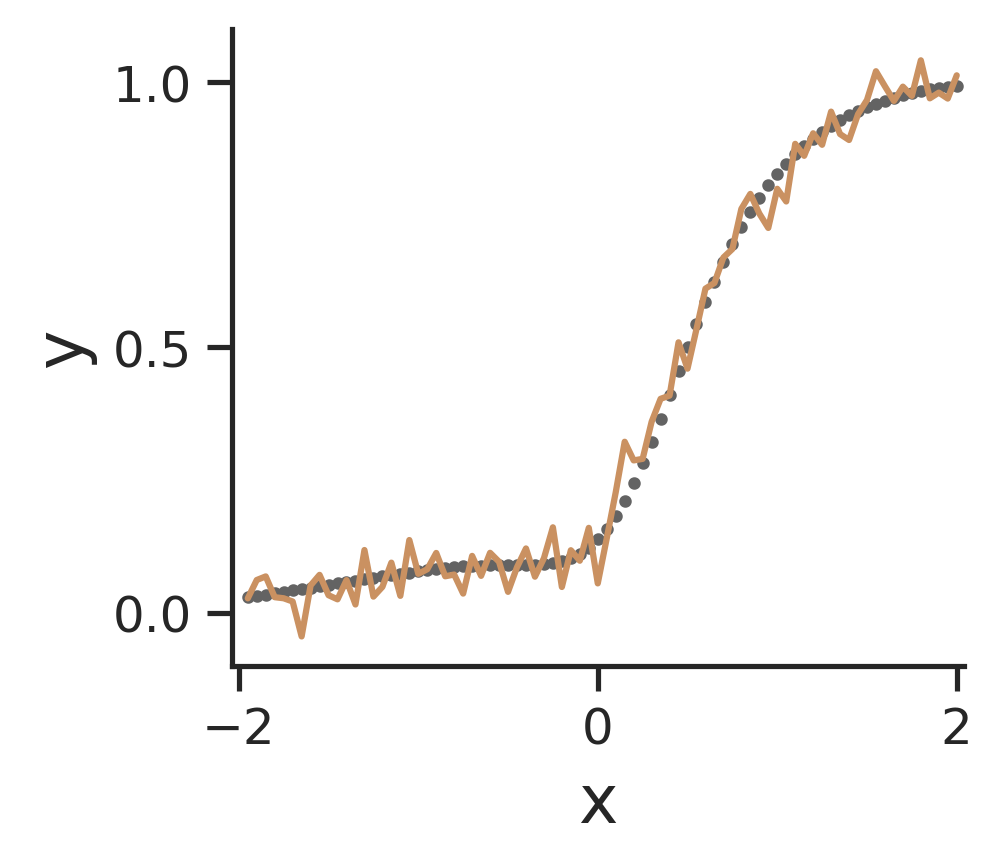

In [21]:
#Read NN and BMS data
function='tanh' #tanh, leaky_ReLU
sigma=0.04;realization=2

path_nn='../data/nns/1x_resolution/approximation/'
file_data= path_nn + 'NN_no_overfit_' + function + '_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
n=8;
d=pd.read_csv(file_data, index_col=0)
dn=d[d['rep']==n]
dn=dn[(dn['x1']>=-2.0) & (dn['x1']<=2.0)] #take points between x=-2/+2

#dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)

fig=figure(figsize=(width,height), dpi=300) 

#calculate root mean squared error
rmse_nn_total=root_mean_squared_error(dn.ymodel,dn.y)

#Plots                                                               
#--------------------------------                                    
plt.plot(dn.x1,dn.y,'.', markersize=marker_s, color=color_data)
plt.plot(dn.x1,dn.y_noise, color=color_noise)
#--------------------------------

#Labels                                                              
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
#Ticks                                                               
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)

sns.despine(top=True, right=True)


#save fig  
name_fig='ann_noise_n' + str(n)
for ext in extensions:
    plt.savefig(output_path+name_fig+ext,dpi=300)

plt.show()
#-------------------------------- 


Now, I am going to train the BMS with 10 parameters and a neural network with 60 points and I am going to test on the remaining 20 points.
For the nn, I am also including 10 validation points, to prevent the neural network to overfit the data.

80
60


<lambdifygenerated-1117>:2: RuntimeWarning: invalid value encountered in power
  return x1 + x1**x1
<lambdifygenerated-1118>:2: RuntimeWarning: invalid value encountered in power
  return x1 + x1**x1
<lambdifygenerated-1127>:2: RuntimeWarning: invalid value encountered in power
  return _a3_**exp(_a5_*x1) + x1


,x1,y,rep,noise,y_noise,ymodel,ybms
59,1.00,0.826911,8.0,-0.027888,0.799023,0.770644,0.819457
60,1.05,0.846376,8.0,-0.071213,0.775163,0.784883,0.841001
61,1.10,0.863906,8.0,0.019867,0.883773,0.797875,0.860892
62,1.15,0.879668,8.0,-0.018469,0.861199,0.809736,0.879209
63,1.20,0.893825,8.0,0.009881,0.903706,0.820571,0.896034
64,1.25,0.906530,8.0,-0.024545,0.881985,0.830476,0.911457
65,1.30,0.917928,8.0,0.026563,0.944490,0.839542,0.925565
66,1.35,0.928148,8.0,-0.025948,0.902200,0.847849,0.938449
67,1.40,0.937310,8.0,-0.046262,0.891048,0.855470,0.950197
68,1.45,0.945519,8.0,-0.005968,0.939551,0.862472,0.960893


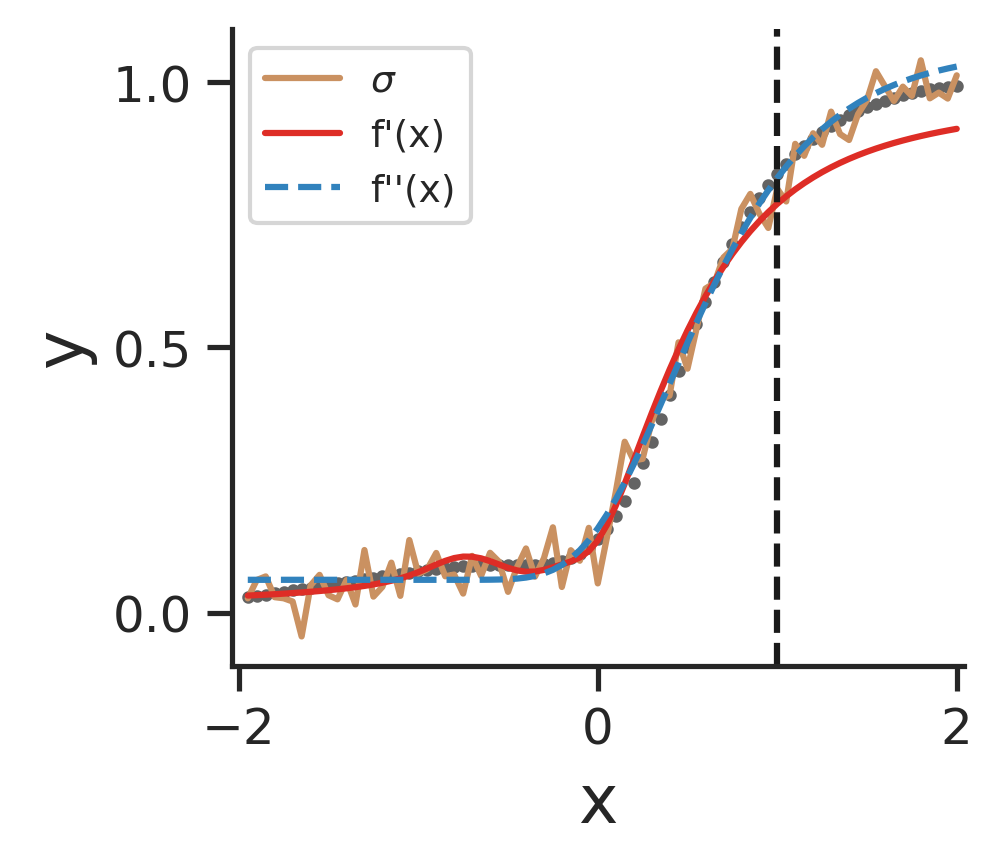

In [90]:
fig=figure(figsize=(width,height), dpi=300) 

path_bms='../data/MSTraces/1x_resolution/'
filename=path_bms +'BMS_' + function + '_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_0.05_trace_'+str(steps)+'_prior_10'+ '.csv'
tracen=pd.read_csv(filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t0,x0,y0=get_mdl(dn, tracen)

#copy the original dataframe and add a column for the prediction of the BMS
dplot = deepcopy(dn)
dplot['ybms'] = t0.predict(x0)

#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=3/4;test_fraction=0.2
train_size=int(n_points*3/4)
print(train_size)
display(dplot.loc[train_size-1:])
train_border=dplot.loc[train_size-1]['x1']


#calculate root mean squared error
#ann errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size-1]['ymodel'],dplot.loc[:train_size -1]['y'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size-1:]['ymodel'],dplot.loc[train_size -1:]['y'])

#bms errors
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size-1]['ybms'],dn.loc[:train_size-1]['y'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size-1:]['ybms'],dn.loc[train_size-1:]['y'])


plt.plot(dn['x1'], dn['y'],'.', markersize=marker_s, color=color_data) 
plt.plot(dn['x1'], dn['y_noise'],linewidth=line_w, markersize=2, color=color_noise,label=r'$\sigma$')
plt.plot(dn['x1'], dn['ymodel'],linewidth=line_w, color=color_ann, label="f'(x)")


plt.plot(dplot.x1, dplot.ybms, color=color_bms, linestyle='--',label="f''(x)" ) 
                                                                                
plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')


#plt.title('n=%d, r=%d' % (n, realization),fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(ytick_labels, fontsize=size_ticks)
plt.xlim(xmin,xmax);plt.ylim(ymin,ymax)
plt.legend(loc='best', fontsize=0.75*size_ticks)

sns.despine(top=True, right=True);

#save fig  
name_fig='ann_bms_noise_n' + str(n)
for ext in extensions:
    plt.savefig(output_path+name_fig+ext,dpi=300)

plt.show()
#-------------------------------- 


For our experiment, we sampled the space of ANN-generated functions and took 20 functions: **10** using **tanh** as an activation function, **10** using the **leaky ReLU**.

We then added Gaussian noise to these functions from $\sigma=0$ to $\sigma=0.2$ in steps of $\Delta \sigma = 0.02$. That gives **11** levels of noise.

Finally, we make **3** realizations of Gaussian noise for each value $\sigma_i$.

That gives **30** simulations of the BMS and ANNs per value of $\sigma_i$

Below, we show the error for each individual simulation in the approximation task.

Let's take a look at a specific example

In [39]:
def get_errors(error_df):
    #read errors
    #errors_approximation=pd.read_csv('../data/'+ 'all_errors_' + resolution +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test", "n", "r"]
    #errors_approximation=errors_approximation[columns]
    errors_approximation=error_df[columns]

    #divide between train/test
    errors_approximation_train=error_df[["sigma","function", "rmse_nn_train", "rmse_mdl_train","n", "r"]]
    errors_approximation_train=pd.melt(errors_approximation_train,id_vars=["sigma","function", "n", "r"], var_name="error_train",value_name= "value_train")   

    errors_approximation_test=error_df[["sigma","function", "rmse_nn_test", "rmse_mdl_test","n", "r"]]
    errors_approximation_test=pd.melt(errors_approximation_test,id_vars= ["sigma","function", "n", "r"], var_name="error_test", value_name= "value_test")

    #Separate tanh and leaky ReLU
    errors_t_tr=errors_approximation_train[errors_approximation_train['function']=='tanh']
    errors_t_tt=errors_approximation_test[errors_approximation_test['function']=='tanh']

    errors_l_tr=errors_approximation_train[errors_approximation_train['function']=='leaky_ReLU']
    errors_l_tt=errors_approximation_test[errors_approximation_test['function']=='leaky_ReLU']
    return errors_t_tr, errors_t_tt, errors_l_tr, errors_l_tt

In [40]:
#read error data
errors_approximation=pd.read_csv('../data/'+ 'all_errors_1x' + '.csv',index_col=0)
errors_tanh_train, errors_tanh_test, errors_leaky_train, errors_leaky_test=get_errors(errors_approximation)

<Figure size 944.882x826.772 with 0 Axes>

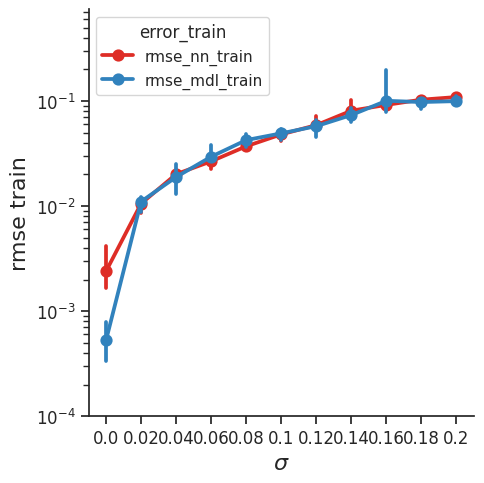

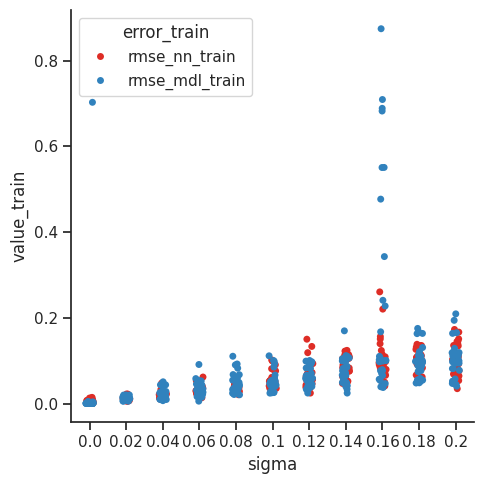

In [41]:
resamples=100000; bs_seed=1111
ymin=1e-4;ymax=0.75

#tanh - rmse approximation
fig=figure(figsize=(width,height), dpi=300)
sns.catplot(data=errors_tanh_train, x='sigma', y='value_train', hue='error_train', kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)


#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse train',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)

plt.ylim(ymin,ymax)

plt.tight_layout()

name_figure='approximations_tanh.png'  
for ext in extensions:
        plt.savefig('../results/' + name_figure +ext,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_tanh_train, x='sigma', y='value_train', hue="error_train",palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

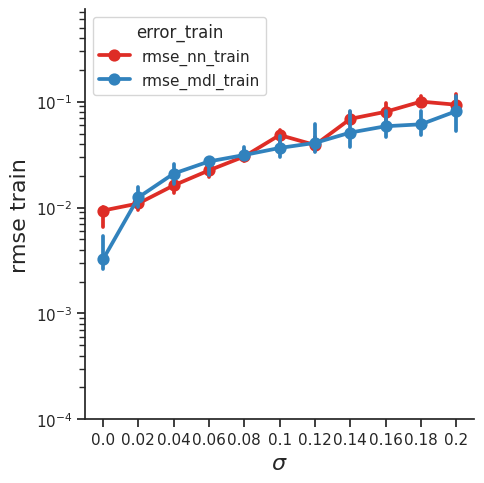

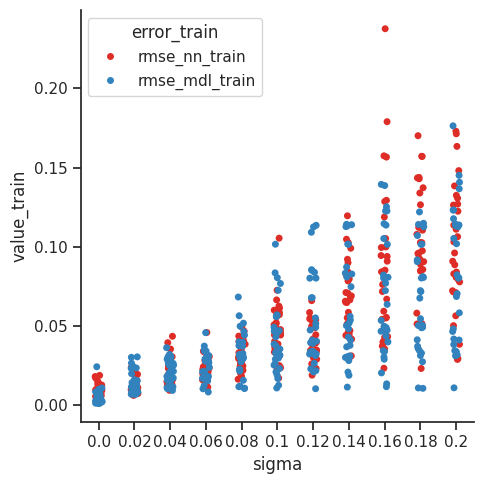

In [42]:
#Approximation: leaky ReLU
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_leaky_train, x='sigma', y='value_train', hue="error_train", kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse train',fontsize=size_axis)

plt.ylim(ymin,ymax)

plt.tight_layout()

name_figure='approximations_leaky.png'
for ext in extensions:
        plt.savefig('../results/' + name_figure +ext,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_leaky_train, x='sigma', y='value_train', hue="error_train",palette=[color_ann, color_bms],legend_out=False)

We now look at the errors on the interpolation and extrapolation tasks

In [43]:
def get_errors_interpolation(resolution='1x'):
    #read errors
    errors_interpolation=pd.read_csv('../data/'+ 'all_errors_interpolation' +  '.csv',index_col=0)
    columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.", "n", "r"]
    errors_interpolation=errors_interpolation[columns]
    display(errors_interpolation)

    #divide between train/test
    errors_interpolation_train=errors_interpolation[["sigma","function", "rmse_nn_interp.", "rmse_mdl_interp.","n", "r"]]
    errors_interpolation_train=pd.melt(errors_interpolation_train,id_vars=["sigma","function", "n", "r"], var_name="error_interp.",value_name= "value_interp.")   

    errors_interpolation_test=errors_interpolation[["sigma","function", "rmse_nn_extrap.", "rmse_mdl_extrap.","n", "r"]]
    errors_interpolation_test=pd.melt(errors_interpolation_test,id_vars= ["sigma","function", "n", "r"], var_name="error_extrap.", value_name= "value_extrap.")

    #Separate tanh and leaky ReLU
    errors_t_tr=errors_interpolation_train[errors_interpolation_train['function']=='tanh']
    errors_t_tt=errors_interpolation_test[errors_interpolation_test['function']=='tanh']

    errors_l_tr=errors_interpolation_train[errors_interpolation_train['function']=='leaky_ReLU']
    errors_l_tt=errors_interpolation_test[errors_interpolation_test['function']=='leaky_ReLU']

    return errors_t_tr, errors_t_tt, errors_l_tr, errors_l_tt

In [44]:
#Read errors and take rmse
resolution='1x' #0.5x, 1x, 2x, 4e-3x
errors_tanh_inter, errors_tanh_extra, errors_leaky_inter, errors_leaky_extra=get_errors_interpolation()

,sigma,function,rmse_nn_interp.,rmse_nn_extrap.,rmse_mdl_interp.,rmse_mdl_extrap.,n,r
0,0.0,tanh,0.012386,0.060146,0.001340,0.011199,0,0
1,0.0,tanh,0.012122,0.026266,0.003454,0.454497,1,0
2,0.0,tanh,0.006643,0.085908,0.001222,0.069993,2,0
3,0.0,tanh,0.001461,0.089270,0.000406,0.048799,3,0
4,0.0,tanh,0.002459,0.014093,0.000248,0.003921,4,0
...,...,...,...,...,...,...,...,...
655,0.2,leaky_ReLU,0.087048,0.182138,0.010784,0.164822,5,2
656,0.2,leaky_ReLU,0.127071,0.610832,0.142086,0.234066,6,2
657,0.2,leaky_ReLU,0.105589,4.418359,0.041496,0.046699,7,2
658,0.2,leaky_ReLU,0.141243,3.278076,0.114628,0.176435,8,2


<Figure size 944.882x826.772 with 0 Axes>

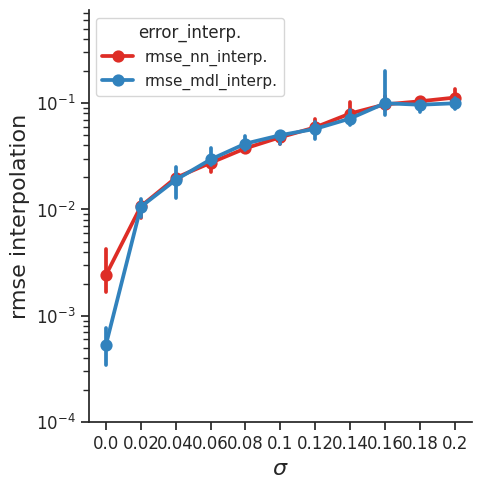

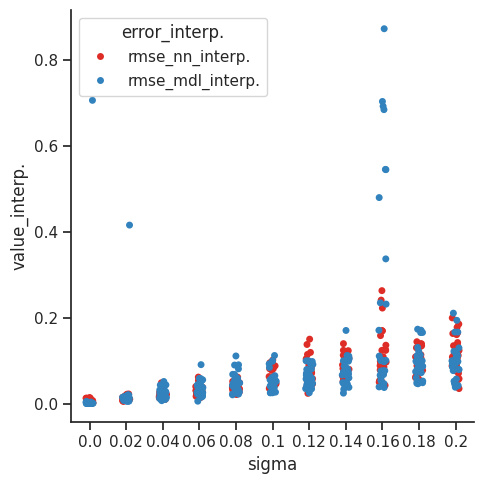

In [45]:
#Interpolation - tanh
fig=figure(figsize=(width,height), dpi=300)
sns.catplot(data=errors_tanh_inter, x='sigma', y='value_interp.', hue="error_interp.", kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)

plt.ylim(ymin,ymax)
name_figure='interpolations_tanh'
for ext in extensions:
        plt.savefig('../results/' + name_figure +ext,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_tanh_inter, x='sigma', y='value_interp.', hue="error_interp.",palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

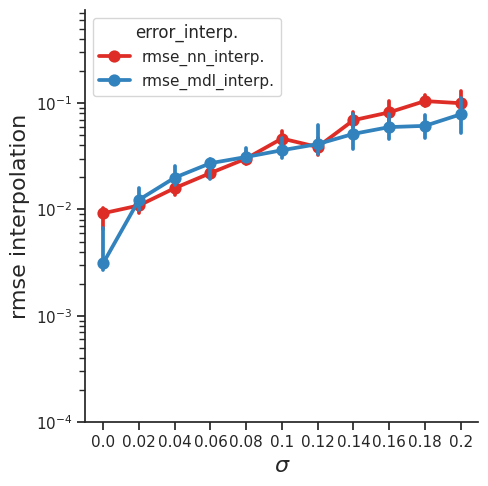

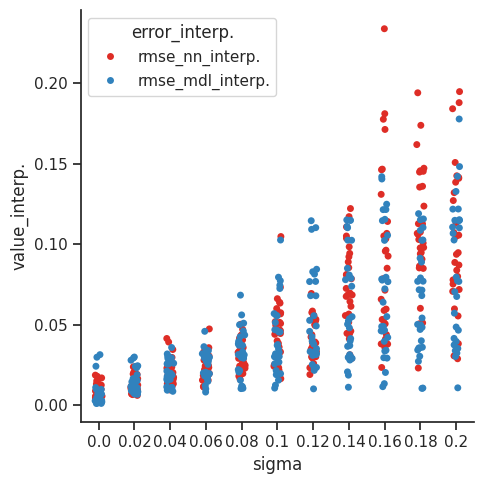

In [46]:
#Interpolation - leaky
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_leaky_inter, x='sigma', y='value_interp.', hue='error_interp.', kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.ylim(ymin,ymax)
name_figure='interpolations_leaky'
for ext in extensions:
        plt.savefig('../results/' + name_figure +ext,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_leaky_inter, x='sigma', y='value_interp.', hue='error_interp.',palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

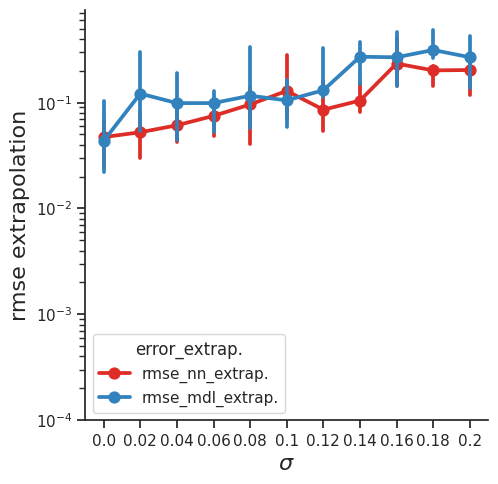

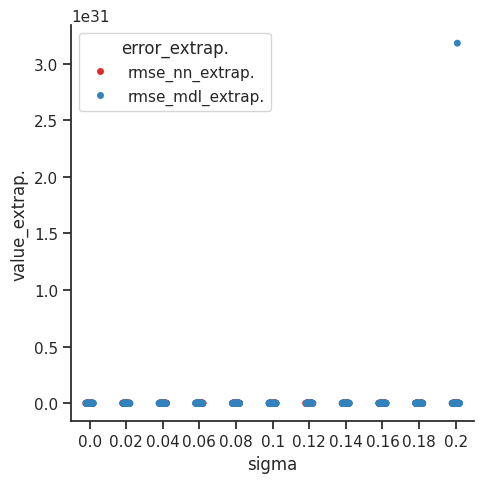

In [47]:
#Extrapolation - tanh
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_tanh_extra, x='sigma', y='value_extrap.', hue="error_extrap.", kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.ylim(ymin,ymax)
name_figure='extrapolations_tanh'
for ext in extensions:
        plt.savefig('../results/' + name_figure +ext,dpi=300)
#Also plot individual errors of each simulation
sns.catplot(data=errors_tanh_extra, x='sigma', y='value_extrap.', hue="error_extrap.",palette=[color_ann, color_bms],legend_out=False)

<Figure size 944.882x826.772 with 0 Axes>

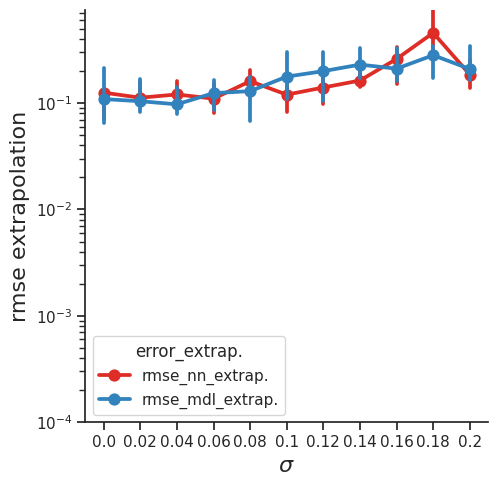

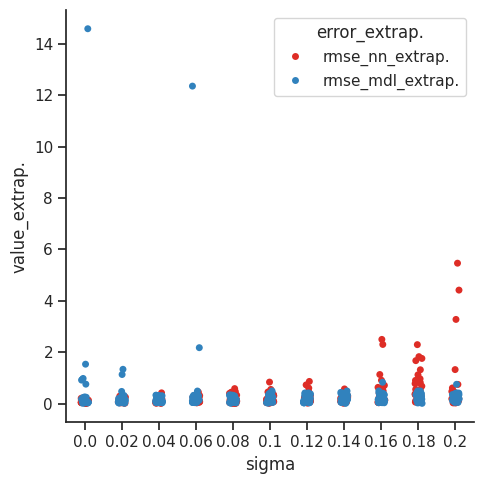

In [48]:
#Extrapolation - leaky
fig=figure(figsize=(width,height), dpi=300)

sns.catplot(data=errors_leaky_extra, x='sigma', y='value_extrap.', hue='error_extrap.', kind='point', estimator='median',
            errorbar=('ci', 95),n_boot=resamples, seed=bs_seed, palette=[color_ann, color_bms],legend_out=False)
plt.yscale("log")

#labels, limits, and ticks
plt.xlabel(r'$\sigma$',fontsize=size_axis) 
plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.ylim(ymin,ymax)
name_figure='extrapolations_leaky'
for ext in extensions:
        plt.savefig('../results/' + name_figure +ext,dpi=300)

#Also plot individual errors of each simulation
sns.catplot(data=errors_leaky_extra, x='sigma', y='value_extrap.', hue='error_extrap.',palette=[color_ann, color_bms],legend_out=False)